# 04 — Correlation and Autocorrelation

This notebook walks through the `Correlation` mixin of the `TimeSeries` class. We focus on **understanding what each method tells us**, not just on running code.

**Data used:** `examples/data/temp.csv` — daily temperature observations. Daily temperature is a classic example of a strongly *autocorrelated* series: today's temperature is very close to yesterday's.

**What you will learn:**
1. The difference between *correlation* (between two variables) and *autocorrelation* (a variable with its own past).
2. How to read an ACF / PACF plot.
3. How Pearson / Spearman / Kendall differ and when to pick each.
4. How to test whether a series is **white noise** using the Ljung-Box test.

## 1. Introduction — Correlation vs Autocorrelation

### Correlation
Correlation measures how two variables move together. Its value is between `-1` and `+1`:

- `+1` — perfect positive (when one rises, the other rises).
- `0`  — no linear relationship.
- `-1` — perfect negative.

Three coefficients are commonly used:

| Coefficient | Measures | Use it when |
|---|---|---|
| **Pearson** | Linear relationship | Both series look roughly normal, no heavy outliers |
| **Spearman** | Monotonic relationship (rank-based) | Data is skewed or you only care about ordering |
| **Kendall** | Monotonic relationship (concordance) | Small samples; very robust but slower |

### Autocorrelation
Autocorrelation is just correlation of a series **with a lagged copy of itself**. If today's value is similar to yesterday's, the lag-1 autocorrelation is high. Most environmental time series (temperature, river flow, stock prices) are strongly autocorrelated — values nearby in time carry information about each other.

Autocorrelation matters because it **violates the assumption of independence** in most classical statistical tests. If you ignore it, p-values can be wildly wrong.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statista.time_series import TimeSeries

# Load daily temperature data
df = pd.read_csv('../../../examples/data/temp.csv', parse_dates=['Date'], index_col='Date')
print('Shape:', df.shape)
print('Date range:', df.index.min(), 'to', df.index.max())
df.head()

Shape: (3650, 1)
Date range: 1981-01-01 00:00:00 to 1990-12-31 00:00:00


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [2]:
# Wrap in TimeSeries
ts = TimeSeries(df)
print('Columns:', list(ts.columns))
ts.head()

Columns: ['Temp']


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


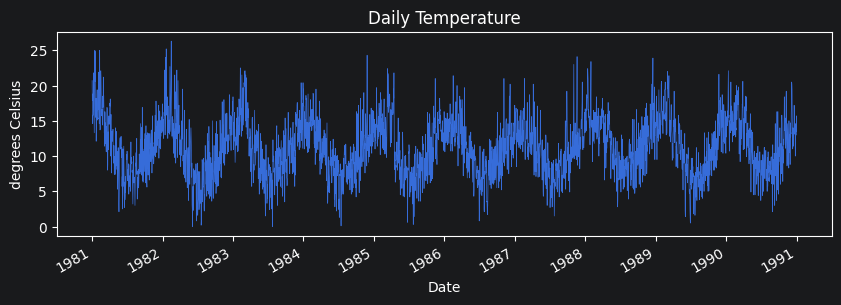

In [3]:
# Quick visual: a strong annual cycle is clearly visible
fig, ax = plt.subplots(figsize=(10, 3))
df['Temp'].plot(ax=ax, linewidth=0.5)
ax.set_title('Daily Temperature')
ax.set_ylabel('degrees Celsius')
plt.show()

## 2. The Autocorrelation Function — `.acf()`

The **ACF** shows the correlation between the series and copies of itself shifted by 1, 2, 3, ... steps (lags).

**How to read an ACF plot:**
- A spike at lag `k` means values `k` steps apart are correlated.
- The **red dashed lines** are the 95% confidence band. Spikes outside the band are statistically significant.
- **Slow decay** -> the series has *long memory* / a trend / is non-stationary.
- **Quick decay** -> short memory.
- **Wave pattern** -> seasonality.

For daily temperature we expect: (a) the first few lags are near `1.0` (yesterday is almost today), (b) correlation decays slowly, and (c) a gentle wave every 365 days from the yearly cycle.

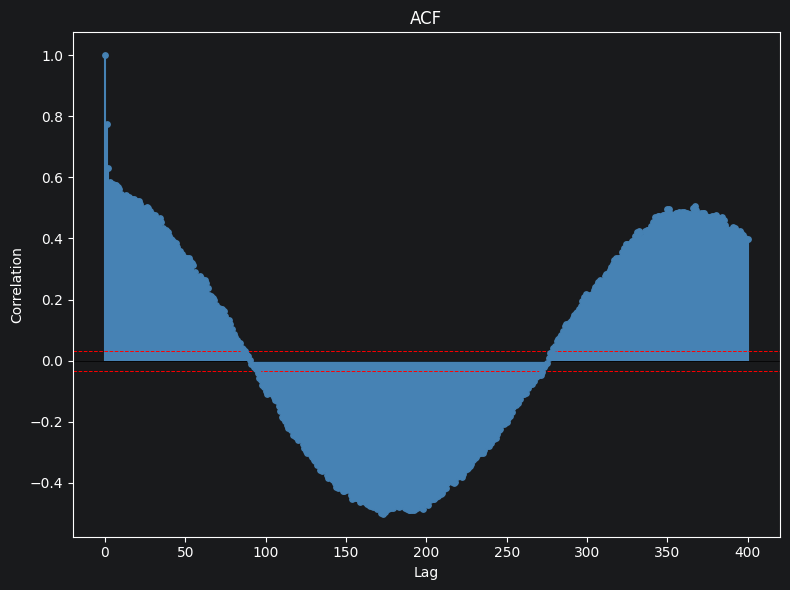

ACF at lag 1: 0.7743
ACF at lag 30: 0.4742
ACF at lag 365 (one year): 0.4788


In [4]:
acf_vals, (fig, ax) = ts.acf(nlags=400, plot=True)
print('ACF at lag 1:', round(float(acf_vals[1]), 4))
print('ACF at lag 30:', round(float(acf_vals[30]), 4))
print('ACF at lag 365 (one year):', round(float(acf_vals[365]), 4))

### What this means for your data

- The lag-1 autocorrelation is very close to `1.0` — today is almost yesterday.
- The ACF oscillates with a period of ~365 days: this is the annual temperature cycle (summer vs. winter).
- The slow decay tells us this series is **not** white noise; any statistical test that assumes independent samples will be misleading.

## 3. The Partial Autocorrelation Function — `.pacf()`

The **PACF** is like the ACF, but with the effect of intermediate lags **removed**.

Imagine today (`t`) depends on yesterday (`t-1`), which depends on the day before (`t-2`). The raw ACF at lag 2 captures both the direct effect of `t-2` on `t` *and* the indirect one through `t-1`. The PACF strips out the indirect part.

**Practical use:** PACF is the classical tool for choosing the order `p` of an **AR(p)** model. The PACF cuts off (drops into the confidence band) at lag `p`.

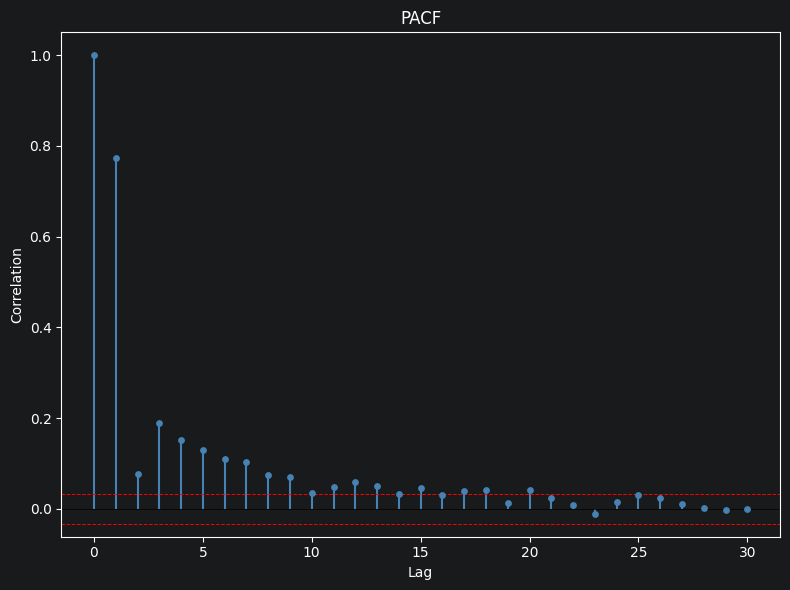

PACF at lag 1: 0.7743
PACF at lag 2: 0.0769
PACF at lag 3: 0.1891


In [5]:
pacf_vals, (fig, ax) = ts.pacf(nlags=30, plot=True)
print('PACF at lag 1:', round(float(pacf_vals[1]), 4))
print('PACF at lag 2:', round(float(pacf_vals[2]), 4))
print('PACF at lag 3:', round(float(pacf_vals[3]), 4))

### What this means for your data

The PACF typically has a large spike at lag 1 and then drops quickly. That is consistent with an **AR(1)**-like process: once you know yesterday, earlier days add little extra information.

## 4. Cross-Correlation — `.cross_correlation()`

Cross-correlation measures how one series relates to a **lagged version of another** series. It is the key tool for finding **lead-lag** relationships: for example, does rainfall upstream predict river flow downstream two days later?

Since `temp.csv` has only one column, we create a second synthetic series (temperature lagged by 3 days with a bit of noise) to demonstrate. The peak of the CCF should appear at lag 3.

In [6]:
# Build a two-column TimeSeries: original and a 3-day lagged noisy copy
rng = np.random.default_rng(42)
temp = df['Temp'].values
lagged = np.concatenate([np.full(3, np.nan), temp[:-3]]) + rng.normal(0, 0.5, size=len(temp))
combined = pd.DataFrame({'station_A': temp, 'station_B': lagged}, index=df.index).dropna()
ts2 = TimeSeries(combined)
ts2.head()

,station_A,station_B
Date,,
1981-01-04,14.6,21.170282
1981-01-05,15.8,16.924482
1981-01-06,15.8,18.148910
1981-01-07,15.8,14.663920
1981-01-08,17.4,15.641879


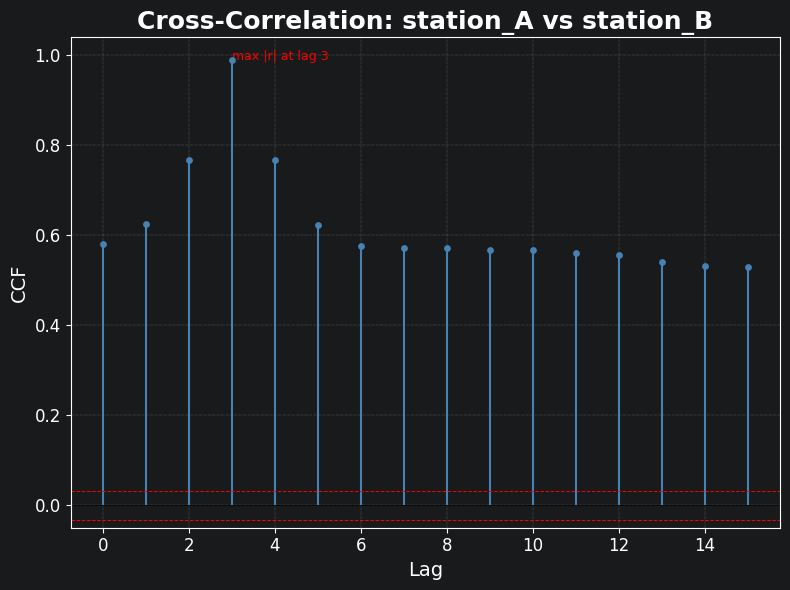

Peak |CCF| at lag: 3
CCF at that lag: 0.9908


In [7]:
ccf_vals, (fig, ax) = ts2.cross_correlation('station_A', 'station_B', nlags=15)
peak_lag = int(np.argmax(np.abs(ccf_vals)))
print('Peak |CCF| at lag:', peak_lag)
print('CCF at that lag:', round(float(ccf_vals[peak_lag]), 4))

### What this means for your data

The maximum correlation sits near lag 3 — exactly the lag we built into the synthetic series. In real applications (e.g. river gauges along a river, or air pressure vs. wind), the peak lag tells you the **travel time** between the two processes.

## 5. Lag Plot — `.lag_plot()`

A **lag plot** is a scatter of `x(t)` against `x(t-lag)`. If the points line up along a diagonal, the series is strongly serially dependent. A blob with no structure means the series looks like white noise at that lag.

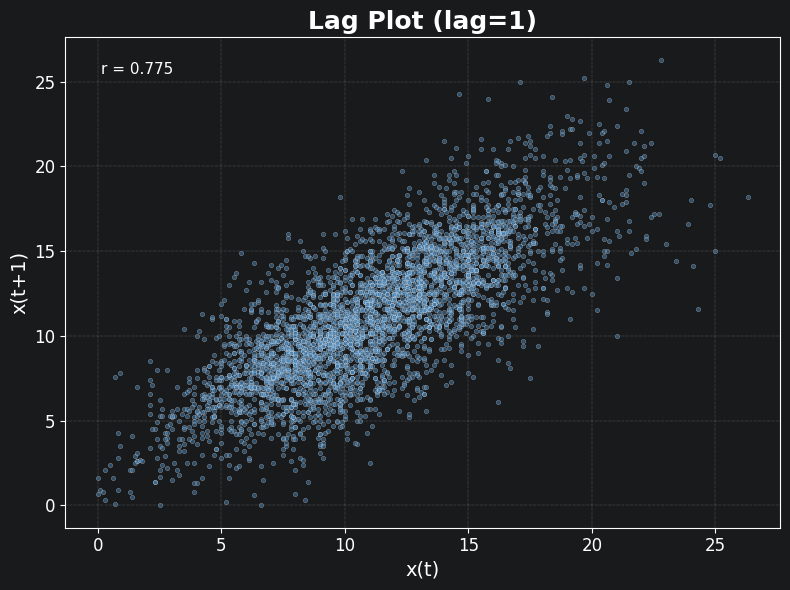

In [8]:
fig, ax = ts.lag_plot(lag=1)
plt.show()

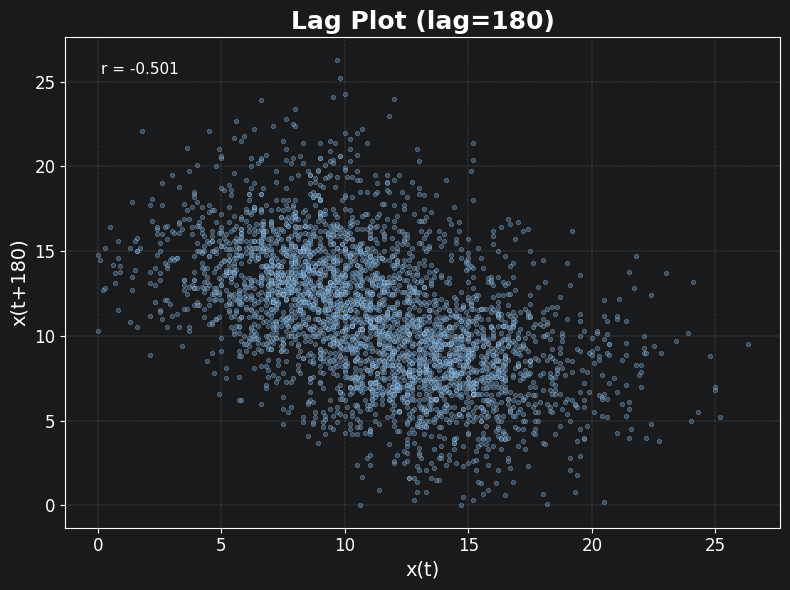

In [9]:
# Compare to a much longer lag — the structure weakens
fig, ax = ts.lag_plot(lag=180)
plt.show()

### What this means for your data

At lag 1 the points form a narrow diagonal cloud — consecutive days are almost identical. At lag 180 the diagonal inverts (summer vs. winter 6 months apart).

## 6. Correlation Matrix with P-Values — `.correlation_matrix()`

The ordinary pandas `.corr()` gives you coefficients but **no p-values**. Without a p-value you cannot tell whether a correlation of, say, `0.12` is real or just random noise.

The `correlation_matrix()` method returns **both** the coefficient and its p-value. In the heatmap, stars mark significance:

- `*`   — p < 0.05
- `**`  — p < 0.01
- `***` — p < 0.001

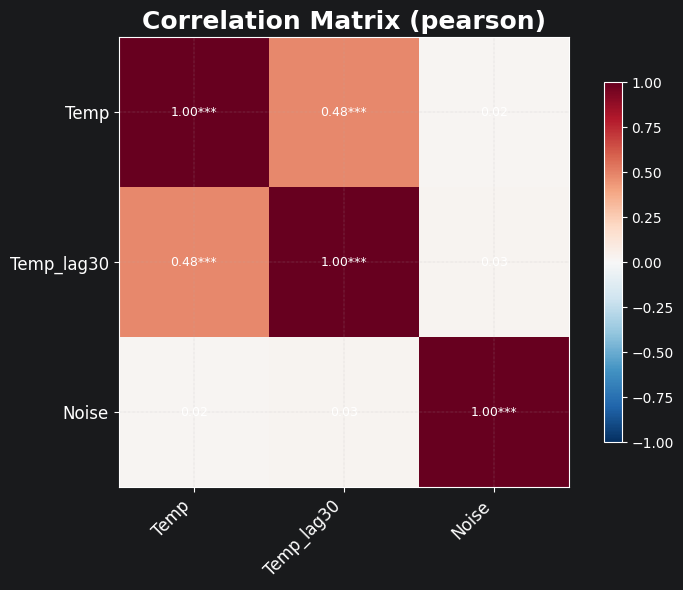

Pearson correlations:
             Temp  Temp_lag30  Noise
Temp        1.000       0.483  0.022
Temp_lag30  0.483       1.000  0.030
Noise       0.022       0.030  1.000

P-values:
              Temp  Temp_lag30   Noise
Temp        0.0000      0.0000  0.1888
Temp_lag30  0.0000      0.0000  0.0724
Noise       0.1888      0.0724  0.0000


In [10]:
# Build a multi-column frame: original temperature, a shifted copy, and noise
rng = np.random.default_rng(0)
multi = pd.DataFrame({
    'Temp': df['Temp'].values,
    'Temp_lag30': np.concatenate([np.full(30, np.nan), df['Temp'].values[:-30]]),
    'Noise': rng.normal(size=len(df)),
}, index=df.index).dropna()
ts_multi = TimeSeries(multi)

corr, pvals, (fig, ax) = ts_multi.correlation_matrix(method='pearson')
print('Pearson correlations:')
print(corr.round(3))
print('\nP-values:')
print(pvals.round(4))

### What this means for your data

- `Temp` vs `Temp_lag30` has a very high coefficient AND a tiny p-value — strong, highly significant dependence.
- `Temp` vs `Noise` is near zero with a large p-value — no real relationship.

**Why p-values matter:** with large samples, even tiny correlations can be "statistically significant" but practically meaningless. Always look at both the size of `r` and its p-value.

In [11]:
# Spearman is robust to outliers and non-linear but monotonic relationships
corr_s, pvals_s, _ = ts_multi.correlation_matrix(method='spearman', plot=False)
print('Spearman correlations:')
print(corr_s.round(3))

Spearman correlations:
             Temp  Temp_lag30  Noise
Temp        1.000       0.513  0.012
Temp_lag30  0.513       1.000  0.032
Noise       0.012       0.032  1.000


## 7. Ljung-Box Test — `.ljung_box()`

The **Ljung-Box** test asks a simple question:

> Are the first `m` autocorrelations of the series *jointly* zero?

- **Null hypothesis (H0):** the series is white noise (no autocorrelation).
- **Alternative (H1):** at least one autocorrelation is non-zero.

**How to interpret:**
- `p-value > 0.05` -> fail to reject H0 -> consistent with white noise.
- `p-value < 0.05` -> reject H0 -> the series has detectable autocorrelation.

This is the standard residual-diagnostic for time-series models: after fitting, the residuals should pass the Ljung-Box test (behave like white noise).

In [12]:
lb = ts.ljung_box(lags=10)
print('Ljung-Box for raw daily temperature:')
print(lb.round(4))

Ljung-Box for raw daily temperature:
       lb_stat  lb_pvalue
1    2189.9409        0.0
2    3641.5342        0.0
3    4893.6217        0.0
4    6113.9604        0.0
5    7332.6675        0.0
6    8542.5361        0.0
7    9749.6508        0.0
8   10929.7393        0.0
9   12082.7685        0.0
10  13177.2277        0.0


### What this means for your data

Every p-value is effectively `0.0`: the series is **very far from white noise**, exactly as the ACF suggested. Any model fit to this series must account for the autocorrelation structure (ARIMA, state-space, etc.).

In [13]:
# For comparison: Ljung-Box on pure white noise
rng = np.random.default_rng(42)
ts_wn = TimeSeries(rng.standard_normal(1000))
print('Ljung-Box for white noise:')
print(ts_wn.ljung_box(lags=10).round(4))

Ljung-Box for white noise:
    lb_stat  lb_pvalue
1    7.6013     0.0058
2    8.6642     0.0131
3    8.6685     0.0340
4    8.7514     0.0676
5    8.8652     0.1146
6    9.8522     0.1310
7   10.9506     0.1408
8   11.0946     0.1964
9   11.3453     0.2528
10  11.3872     0.3282


## Summary

| Method | Answers | Watch out for |
|---|---|---|
| `acf` | How does `x(t)` depend on its past? | Slow decay = non-stationary |
| `pacf` | Direct dependence on lag `k`, controlling for intermediate lags | Useful for AR order selection |
| `cross_correlation` | Lead/lag link between two series | Peak location = lag magnitude |
| `lag_plot` | Visual check of serial dependence | Diagonal = dependence; blob = independence |
| `correlation_matrix` | Coefficient **and** p-value for each pair | Large samples inflate significance |
| `ljung_box` | Is this series white noise? | Reject H0 = residuals still have structure |

**Next up:** notebook 05 shows how to test whether a series is *stationary* — a prerequisite for most of the modelling tools above.